# Time Series Analysis of UK Housing Prices

This notebook performs time-series analysis on UK housing data using construction year as the time dimension.

**Main Tasks:**
- Construct yearly average House Price and Price per Square Foot
- Stationarity testing (ADF test)
- ARIMA modeling and model selection
- Compare ARIMA(4,1,0) and ARIMA(3,1,0)
- Out-of-sample forecasting

**Data Source**: `data/processed/house_price_reg_processed.csv`
**Output Figures**: `results/figures/`
**Output Data**: `code/time_series/outputs/`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
import warnings

warnings.filterwarnings("ignore")

# Plot style
plt.style.use('seaborn-v0_8')
%matplotlib inline

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
# Project paths
data_path = Path('../../data/processed/house_price_reg_processed.csv')
figures_dir = Path('../../results/figures/')
outputs_dir = Path('../../code/time_series/outputs/')

# Create directories
figures_dir.mkdir(parents=True, exist_ok=True)
outputs_dir.mkdir(parents=True, exist_ok=True)

print(f"Data path: {data_path}")
print(f"Figures will be saved to: {figures_dir}")
print(f"Model outputs will be saved to: {outputs_dir}")

Data path: ..\..\data\processed\house_price_reg_processed.csv
Figures will be saved to: ..\..\results\figures
Model outputs will be saved to: ..\..\code\time_series\outputs


In [4]:
# Load processed dataset
df = pd.read_csv(data_path)
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Convert Year_Built to integer and handle any invalid values
df['Year_Built'] = pd.to_numeric(df['Year_Built'], errors='coerce')
df = df.dropna(subset=['Year_Built'])
df['Year_Built'] = df['Year_Built'].astype(int)

print(f"Valid years range: {df['Year_Built'].min()} - {df['Year_Built'].max()}")

Dataset loaded: 1,000 rows × 11 columns
Valid years range: 1950 - 2022


In [5]:
# Average House Price by Year
avg_price_by_year = df.groupby('Year_Built')['House_Price'].mean()

# Average Price per Sqft by Year
avg_price_per_sqft_by_year = df.groupby('Year_Built')['Price_Per_Sqft'].mean()

# Convert index to datetime (start of year)
avg_price_by_year.index = pd.to_datetime(avg_price_by_year.index.astype(str) + '-01-01')
avg_price_per_sqft_by_year.index = pd.to_datetime(avg_price_per_sqft_by_year.index.astype(str) + '-01-01')

print("Yearly average series created.")
print(f"Number of years: {len(avg_price_per_sqft_by_year)}")

Yearly average series created.
Number of years: 73


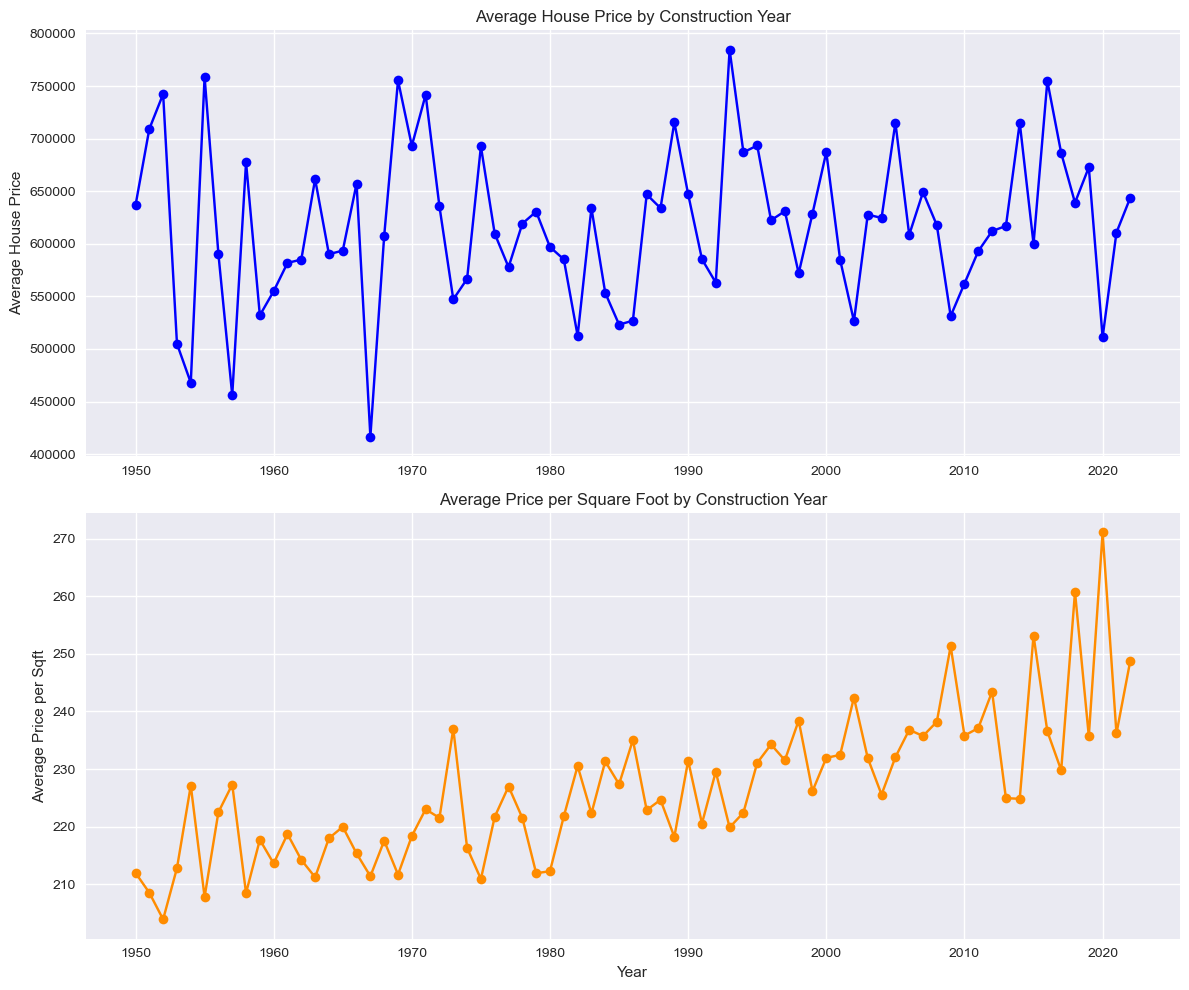

Historical trends plot saved: historical_price_trends.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# House Price
axes[0].plot(avg_price_by_year.index, avg_price_by_year, marker='o', linestyle='-', color='blue')
axes[0].set_title('Average House Price by Construction Year')
axes[0].set_ylabel('Average House Price')
axes[0].grid(True)

# Price per Sqft
axes[1].plot(avg_price_per_sqft_by_year.index, avg_price_per_sqft_by_year, marker='o', linestyle='-', color='darkorange')
axes[1].set_title('Average Price per Square Foot by Construction Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Price per Sqft')
axes[1].grid(True)

plt.tight_layout()
plt.savefig(figures_dir / 'historical_price_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Historical trends plot saved: historical_price_trends.png")

In [7]:
def adf_test(series, title):
    result = adfuller(series)
    print(f"\n=== ADF Test: {title} ===")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values: {result[4]}")
    
    if result[1] < 0.05:
        print("Stationary (reject null hypothesis)")
    else:
        print("Non-stationary (need differencing)")
    return result

adf_test(avg_price_by_year, "Average House Price")
adf_test(avg_price_per_sqft_by_year, "Average Price per Sqft")


=== ADF Test: Average House Price ===
ADF Statistic: -7.6764
p-value: 0.0000
Critical Values: {'1%': -3.524624466842421, '5%': -2.9026070739026064, '10%': -2.5886785262345677}
Stationary (reject null hypothesis)

=== ADF Test: Average Price per Sqft ===
ADF Statistic: 1.3520
p-value: 0.9969
Critical Values: {'1%': -3.5443688564814813, '5%': -2.9110731481481484, '10%': -2.5931902777777776}
Non-stationary (need differencing)


(1.3520386417090433,
 0.996884986938638,
 12,
 60,
 {'1%': -3.5443688564814813,
  '5%': -2.9110731481481484,
  '10%': -2.5931902777777776},
 440.7573248452112)

In [8]:
# ====================== Auto ARIMA Model Selection ======================
print("=== Auto ARIMA Model Selection for Price per Sqft ===")

auto_model = pm.auto_arima(
    avg_price_per_sqft_by_year,
    seasonal=False,
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    max_p=6,
    max_q=3,
    information_criterion='aic'
)

print("\nBest ARIMA model found by auto_arima:")
print(auto_model.summary())

# Save auto_arima summary
with open(outputs_dir / 'auto_arima_summary.txt', 'w') as f:
    f.write(str(auto_model.summary()))

print(f"\n Best model from auto_arima: ARIMA{auto_model.order} (with intercept)")

=== Auto ARIMA Model Selection for Price per Sqft ===
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=566.850, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=538.723, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=564.980, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=528.835, Time=0.04 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=527.951, Time=0.05 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=527.673, Time=0.06 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AIC=528.832, Time=0.08 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(4,1,0)(0,0,0)[0]             : AIC=528.365, Time=0.04 sec

Best model:  ARIMA(4,1,0)(0,0,0)[0] intercept
Total fit time: 1.191 seconds



In [9]:
# ====================== Sensitivity Analysis ======================
# We perform sensitivity analysis by testing models around the best model 
# from auto_arima. Both with and without intercept are tested for robustness.

print("=== Sensitivity Analysis: Testing Nearby ARIMA Models ===")

# Get best order from auto_arima
best_order = auto_model.order
best_p, best_d, best_q = best_order

print(f"Best model from auto_arima: ARIMA({best_p}, {best_d}, {best_q}) with intercept")

# Dynamically generate nearby candidate orders (±1 around best p and q)
candidate_orders = []
for p in range(max(0, best_p - 1), best_p + 2):
    for q in range(max(0, best_q - 1), best_q + 2):
        candidate_orders.append((p, best_d, q))

# Remove duplicates while preserving order
candidate_orders = list(dict.fromkeys(candidate_orders))

models_dict = {}
results_list = []

print(f"Testing {len(candidate_orders)} nearby models (with/without intercept)...\n")

for order in candidate_orders:
    for trend in ['c', 'n']:        # 'c' = with constant (intercept), 'n' = no intercept
        try:
            model = ARIMA(avg_price_per_sqft_by_year, order=order, trend=trend)
            results = model.fit()
            
            model_name = f"ARIMA{order} (trend='{trend}')"
            models_dict[model_name] = results
            
            results_list.append({
                'Model': model_name,
                'Order': order,
                'Trend': trend,
                'AIC': results.aic,
                'BIC': results.bic,
                'Log Likelihood': results.llf
            })
            
            print(f"{model_name} → AIC = {results.aic:.3f}")
        except Exception:
            continue

# Create comparison table and rank by AIC
comparison_df = pd.DataFrame(results_list)
comparison_df = comparison_df.sort_values(by='AIC').reset_index(drop=True)
comparison_df['Rank'] = comparison_df.index + 1

print("\n=== Top 5 Models by AIC (Sensitivity Analysis) ===")
print(comparison_df.head(5)[['Rank', 'Model', 'AIC', 'BIC']].round(3))

# Save full comparison
comparison_df.to_csv(outputs_dir / 'sensitivity_analysis_arima.csv', index=False)
print(f"\n Sensitivity analysis table saved to: {outputs_dir}/sensitivity_analysis_arima.csv")

=== Sensitivity Analysis: Testing Nearby ARIMA Models ===
Best model from auto_arima: ARIMA(4, 1, 0) with intercept
Testing 6 nearby models (with/without intercept)...

ARIMA(3, 1, 0) (trend='n') → AIC = 527.882
ARIMA(3, 1, 1) (trend='n') → AIC = 526.686
ARIMA(4, 1, 0) (trend='n') → AIC = 528.365
ARIMA(4, 1, 1) (trend='n') → AIC = 528.645
ARIMA(5, 1, 0) (trend='n') → AIC = 529.965
ARIMA(5, 1, 1) (trend='n') → AIC = 530.625

=== Top 5 Models by AIC (Sensitivity Analysis) ===
   Rank                       Model      AIC      BIC
0     1  ARIMA(3, 1, 1) (trend='n')  526.686  538.069
1     2  ARIMA(3, 1, 0) (trend='n')  527.882  536.989
2     3  ARIMA(4, 1, 0) (trend='n')  528.365  539.749
3     4  ARIMA(4, 1, 1) (trend='n')  528.645  542.305
4     5  ARIMA(5, 1, 0) (trend='n')  529.965  543.625

 Sensitivity analysis table saved to: ..\..\code\time_series\outputs/sensitivity_analysis_arima.csv



=== Generating Forecast Comparison Plot (Top 3 Models) ===


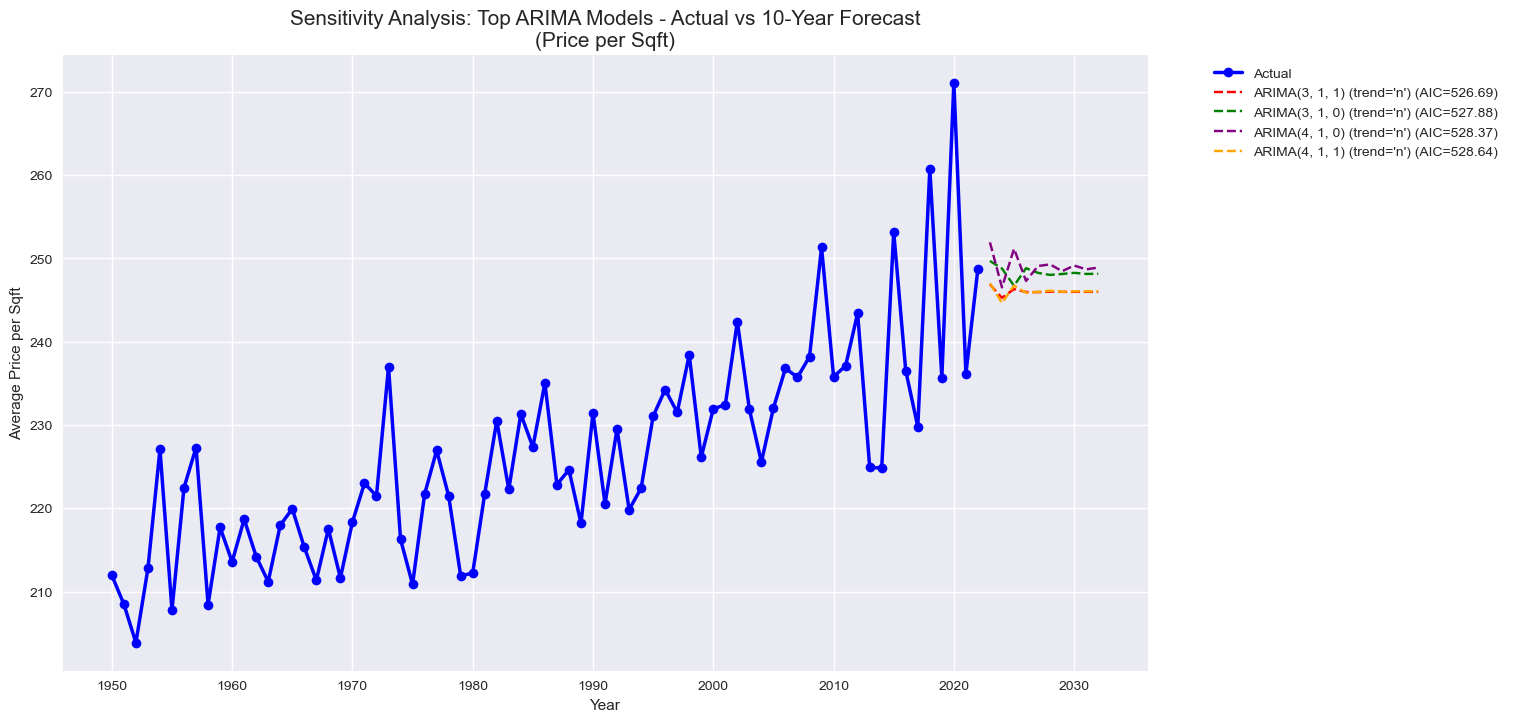

Sensitivity analysis forecast plot saved: sensitivity_analysis_forecast.png


In [10]:
# ====================== Forecast Comparison - Top 3 Models ======================
print("\n=== Generating Forecast Comparison Plot (Top 3 Models) ===")

n_periods = 10
last_year = avg_price_per_sqft_by_year.index[-1].year
forecast_index = pd.date_range(start=f"{last_year + 1}-01-01", periods=n_periods, freq='AS')

plt.figure(figsize=(14, 8))

# Plot actual values
plt.plot(avg_price_per_sqft_by_year, label='Actual', marker='o', color='blue', linewidth=2.5)

colors = ['red', 'green', 'purple', 'orange']

for i in range(min(4, len(comparison_df))):   # Show top 4 at most
    model_name = comparison_df.loc[i, 'Model']
    model_fit = models_dict[model_name]
    
    forecast = model_fit.forecast(steps=n_periods)
    forecast_series = pd.Series(forecast, index=forecast_index)
    
    plt.plot(forecast_series, 
             label=f'{model_name} (AIC={comparison_df.loc[i, "AIC"]:.2f})',
             marker='x', linestyle='--', color=colors[i % len(colors)])

plt.title('Sensitivity Analysis: Top ARIMA Models - Actual vs 10-Year Forecast\n(Price per Sqft)', 
          fontsize=15)
plt.xlabel('Year')
plt.ylabel('Average Price per Sqft')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.savefig(figures_dir / 'sensitivity_analysis_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Sensitivity analysis forecast plot saved: sensitivity_analysis_forecast.png")


 Recommended Model: ARIMA(3, 1, 1) (trend='n')
AIC = 526.686

Last 5 actual years + 10-year forecast (Recommended Model):
    Year  Price_Per_Sqft
0   2018          260.76
1   2019          235.71
2   2020          271.10
3   2021          236.17
4   2022          248.79
5   2023          246.88
6   2024          245.28
7   2025          246.32
8   2026          245.98
9   2027          245.96
10  2028          246.02
11  2029          245.99
12  2030          245.99
13  2031          246.00
14  2032          245.99


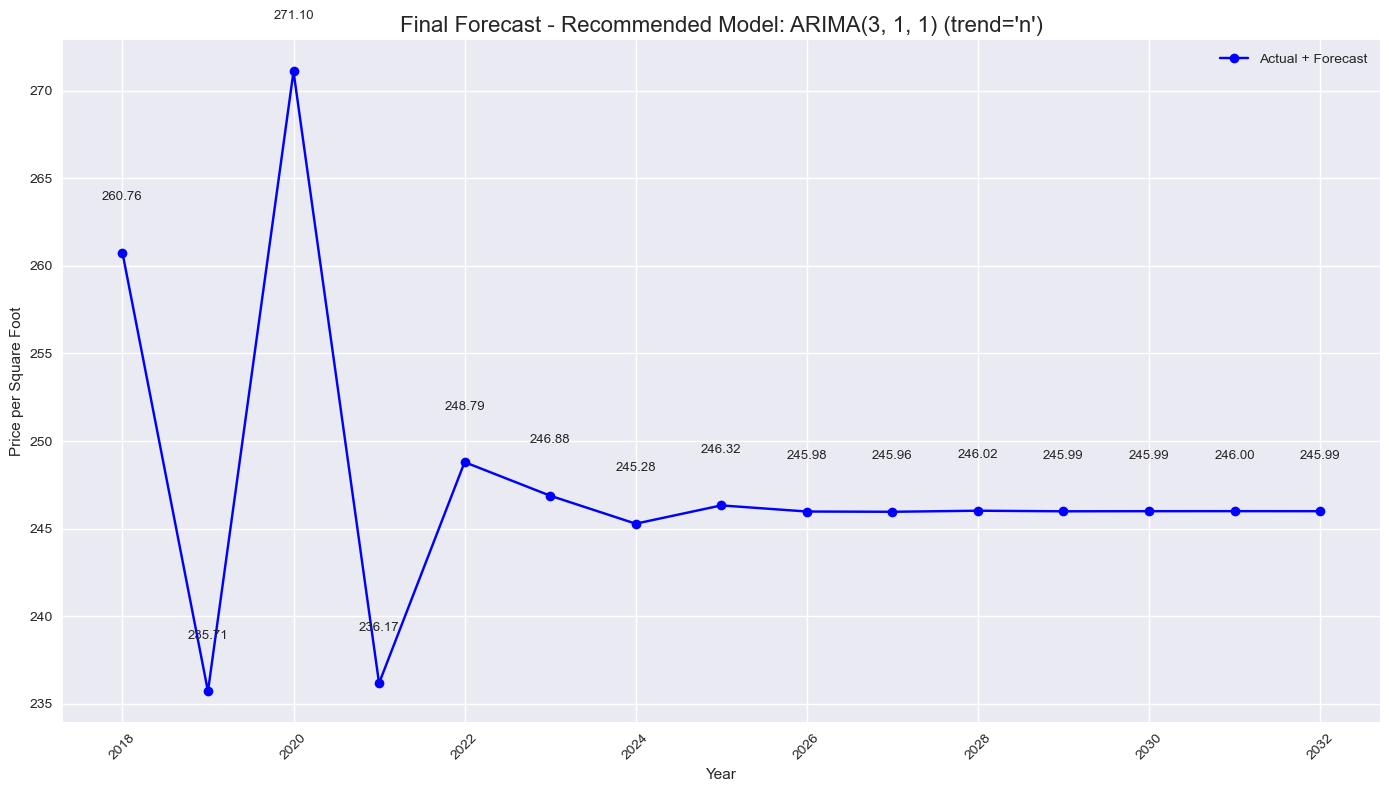

Final forecast table saved: ..\..\code\time_series\outputs/final_forecast_recommended.csv


In [11]:
# ====================== Final Recommendation & Forecast ======================
# Select the overall best model from sensitivity analysis
best_row = comparison_df.iloc[0]
best_model_name = best_row['Model']
best_model = models_dict[best_model_name]

print(f"\n Recommended Model: {best_model_name}")
print(f"AIC = {best_row['AIC']:.3f}")

# Last 5 years actual + 10 years forecast
last_5 = avg_price_per_sqft_by_year[-5:].copy()
forecast_best = best_model.forecast(steps=10)
forecast_series_best = pd.Series(forecast_best, index=forecast_index)

combined = pd.concat([last_5, forecast_series_best])
combined_df = combined.reset_index()
combined_df.columns = ['Year', 'Price_Per_Sqft']
combined_df['Year'] = combined_df['Year'].dt.year

print("\nLast 5 actual years + 10-year forecast (Recommended Model):")
print(combined_df.round(2))

# Plot with value labels
plt.figure(figsize=(14, 8))
plt.plot(combined_df['Year'], combined_df['Price_Per_Sqft'], 
         marker='o', color='blue', label='Actual + Forecast')

for i in range(len(combined_df)):
    plt.text(combined_df['Year'][i], 
             combined_df['Price_Per_Sqft'][i] + 3,
             f"{combined_df['Price_Per_Sqft'][i]:.2f}", 
             ha='center', fontsize=9.5)

plt.title(f'Final Forecast - Recommended Model: {best_model_name}', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Price per Square Foot')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(figures_dir / 'final_forecast_recommended_model.png', dpi=300, bbox_inches='tight')
plt.show()

# Save final forecast table
combined_df.to_csv(outputs_dir / 'final_forecast_recommended.csv', index=False)
print(f"Final forecast table saved: {outputs_dir}/final_forecast_recommended.csv")